# DRN antidromic optotagging — PrL vs S1

DRN counterpart of `F_antidromic_combined.ipynb` (LC-NE). Every DRN unit that passes
opto QC was probed with light at **two** cortical surface sites in the same session,
so the PrL-vs-S1 comparison is **paired within unit** with identical spike sorting,
drift handling and stimulation parameters.

**Questions**
1. How often does each target site yield an antidromic-looking response, and does that
   differ between PrL and S1 once the comparison is paired (McNemar, not chi-square)?
2. Is any difference explained by stimulation parameters rather than connectivity?
3. Do response latency / jitter / collision behaviour differ between sites?
4. Do PrL- and S1-responsive units sit in different parts of the DR?
5. Do they have different waveforms (and are they the opto-tagged 5-HT units)?
6. Does anything survive treating the session / animal as the replicate?

**Two tier schemes are reported side by side** and must not be mixed:

| scheme | where | criteria |
|---|---|---|
| nested per-session tiers (`responsive` / `sharp` / `collision_confirmed`) | `antidromic_tier_categorization` in `antidromic_funcs.py` | `opto_p_val` < 0.05, jitter < 7 ms, latency <= 25 ms, Fisher collision at 0.05 |
| regression flags (`reg_*`) | `session_combine/figure_preparation/antidromic_generation.py` | `p_antidromic` / `p_collision` < 0.005 with positive t, jitter < 10 ms |

The per-session pkls must be regenerated (`python regenerate_antidromic_pkls.py`) and
`antidromic_generation.py` rerun before this notebook, or the tier labels arrive as NaN.

In [1]:
import os
import sys
import json
import pickle
import warnings

sys.path.append('/root/capsule/code/beh_ephys_analysis')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

from scipy import stats
from statsmodels.stats.multitest import multipletests
from statsmodels.stats.contingency_tables import mcnemar
from sklearn.metrics import cohen_kappa_score
from trimesh import load_mesh

from utils.beh_functions import session_dirs
from utils.capsule_migration import capsule_directories
from utils.ccf_utils import project_to_plane
from utils.combine_tools import (
    apply_qc,
    spatial_dependence_summary,
    welch_shift_X_vs_Y,
    binary_shift_X_vs_Y,
)
from utils.functional_features import WAVEFORM_FEATURES

capsule_dirs = capsule_directories()
%matplotlib inline
pd.set_option('display.width', 220)
pd.set_option('display.max_columns', 60)
print('waveform features:', WAVEFORM_FEATURES)

waveform features: ['post_w', 'trough_post_ratio_1D', 'post_trough_slope', 'pre_slope', 'symmetry_slope_div_log', 'symmetry_trough_dis', 'symmetry_inte_div_log']


## 1. Configuration

In [2]:
criteria_name = 'basic_ephys_low_DRN'
data_type = 'raw'
focuses = ['PrL', 'S1']
soma_site = 'surface_DRN'
waveform_version = '_raw'

UNIT_KEY = ['session', 'unit']
CCF_COLS = ['x_ccf', 'y_ccf', 'z_ccf']
# Unit coordinates are stored in absolute LPS mm; subtract this origin for bregma-relative mm.
# DR_bregma_lps_mm.obj is ALREADY bregma-relative LPS mm and must not be shifted.
BREGMA_LPS_MM = np.array([-5.74, 5.4, -0.45])
MIRROR_ML = True
mesh_file = '/root/capsule/data/ccf_meshes/DR_bregma_lps_mm.obj'

# Regression-flag thresholds, identical to antidromic_generation.py.
REG_ALPHA = 0.005
REG_JITTER = 0.010
# Nested per-session tier thresholds, for reference (set in antidromic_funcs.py).
TIER_ALPHA, TIER_JITTER, TIER_MAX_LATENCY = 0.05, 0.007, 0.025

# Pulse-locked response-probability windows (s). The laser pulse is 5 ms and spikes inside
# it are already removed upstream, so the evoked window starts at the end of the pulse.
EVOKED_WINDOW = (0.005, 0.025)
BASELINE_WINDOW = (-0.025, -0.005)

N_PERM_SPATIAL = 1000
K_NEIGHBORS = 15
N_PERM_SHIFT = 5000
SEED = 0

prep_dir = str(capsule_dirs['manuscript_fig_prep_dir'])
antidromic_prep_dir = os.path.join(prep_dir, 'antidromic_analysis')
target_folder = os.path.join(capsule_dirs['manuscript_fig_dir'], 'F_antidromic_DRN')
os.makedirs(target_folder, exist_ok=True)

FOCUS_COLORS = {'PrL': '#1f77b4', 'S1': '#d62728'}
GROUP_ORDER = ['both', 'PrL only', 'S1 only', 'neither']
GROUP_COLORS = {'both': '#7b3294', 'PrL only': '#1f77b4', 'S1 only': '#d62728', 'neither': '#999999'}

# Binary pass criteria evaluated per (unit, site).
CRITERIA = [
    'responsive',               # nested tier 3+: significant light-evoked response
    'sharp',                    # nested tier 2+: + sharp short-latency first-spike peak
    'collision_confirmed',      # nested tier 1: + Fisher collision
    'reg_antidromic',           # regression: p_antidromic < 0.005, t > 0
    'reg_sharp_antidromic',     # regression + jitter < 10 ms
    'reg_antidromic_collision',  # regression antidromic + collision
]
GROUP_CRITERION = 'responsive'      # well-powered, used for the anatomy/waveform groups
SECONDARY_CRITERION = 'reg_sharp_antidromic'

def savefig(fig, name):
    for ext in ('pdf', 'png'):
        fig.savefig(os.path.join(target_folder, f'{name}.{ext}'), dpi=300, bbox_inches='tight')
    print('saved', os.path.join(target_folder, name))

def safe_divide(num, den, eps=1e-10):
    num = np.asarray(num, dtype=float)
    den = np.asarray(den, dtype=float)
    out = np.full(np.broadcast_shapes(num.shape, den.shape), np.nan, dtype=float)
    valid = np.isfinite(num) & np.isfinite(den) & (np.abs(den) > eps)
    np.divide(num, den, out=out, where=valid)
    return out

def ccf_to_bregma_relative(df):
    ccf = df[CCF_COLS].to_numpy(dtype=float).copy() - BREGMA_LPS_MM
    if MIRROR_ML:
        ccf[:, 0] = np.abs(ccf[:, 0])
    return ccf

def fmt_p(p):
    return 'n.s.' if not np.isfinite(p) else ('p<1e-4' if p < 1e-4 else f'p={p:.3g}')

print('figures ->', target_folder)

figures -> /root/capsule/scratch/results/manuscript/figures/F_antidromic_DRN


## 2. Load the QC'd unit table, waveforms and the combined antidromic frame

In [3]:
combined_unit_file = os.path.join(prep_dir, 'combined_unit_tbl', 'combined_unit_tbl.pkl')
criteria_file = os.path.join(
    '/root/capsule/code/beh_ephys_analysis/session_combine/metrics', f'{criteria_name}.json')
wf_file = os.path.join(prep_dir, 'waveforms_np', 'combined_features.csv')
antidromic_file = os.path.join(antidromic_prep_dir, 'combined_antidromic_results.pkl')

with open(combined_unit_file, 'rb') as f:
    combined_tagged_units = pickle.load(f)
with open(criteria_file, 'r') as f:
    constraints = json.load(f)

units_qc, combined_tagged_units, fig, axes = apply_qc(combined_tagged_units, constraints)
if fig is not None:
    fig.savefig(os.path.join(target_folder, 'quality_metrics.pdf'), bbox_inches='tight')
    plt.close(fig)
units_qc = units_qc.copy()
units_qc['unit'] = units_qc['unit'].astype(int)

with open(antidromic_file, 'rb') as f:
    antidromic_wide = pickle.load(f)

print('QC-passing (opto) units:', len(units_qc), 'sessions:', units_qc.session.nunique())
print('antidromic frame:', antidromic_wide.shape)
print('sites:', sorted({c[1] for c in antidromic_wide.columns if c[1]}))
assert not units_qc.duplicated(UNIT_KEY).any()

Applying bounds for isi_violations: [0.0, 0.5]
 - isi_violations: 951 -> 781 units passed
Applying items for qc_pass: [True]
 - qc_pass: 781 -> 686 units passed
Applying bounds for peak: [-1000, 500]
 - peak: 686 -> 686 units passed
Applying opto conditions: ['p_max', 'eu', 'corr', 'tag_loc', 'lat_max_p', 'p_mean', 'sig_counts']


Number of opto rows after filtering: 319
Number of non-opto rows after filtering: 686


QC-passing (opto) units: 319 sessions: 46
antidromic frame: (397, 92)
sites: ['surface_BLA', 'surface_DRN', 'surface_PrL', 'surface_S1']


In [4]:
# Normalized raw waveforms, using the same convention as F_waveform_space_DRN_v2.
wf_col = f'wf{waveform_version}'
all_wfs = np.stack(units_qc[wf_col].to_numpy())
baseline = np.nanmean(all_wfs[:, :3], axis=1)
denom = all_wfs[:, 30] - baseline
valid_norm = np.isfinite(denom) & (np.abs(denom) > 1e-10)
wfs_nl = np.full_like(all_wfs, np.nan, dtype=float)
wfs_nl[valid_norm] = (all_wfs[valid_norm] - baseline[valid_norm, None]) / denom[valid_norm, None]
# Old bad-shape rule: reject units whose raw-normalized first sample exceeds the trough.
raw_norm = safe_divide(all_wfs, all_wfs[:, 30][:, None])
bad_shape = np.isfinite(raw_norm[:, 0]) & (raw_norm[:, 0] > 1)
wfs_nl[bad_shape] = np.nan

waveform_lookup = units_qc[UNIT_KEY].copy()
waveform_lookup['wf_nl'] = list(wfs_nl)
waveform_lookup['wf_norm_valid'] = np.isfinite(wfs_nl).all(axis=1)
pc_time = (np.arange(all_wfs.shape[1]) - 30) / 30000 * 1000

wf_features = pd.read_csv(wf_file)
wf_features['unit'] = wf_features['unit'].astype(int)
wf_feature_cols = [c for c in WAVEFORM_FEATURES if c in wf_features.columns]
wf_features = wf_features[UNIT_KEY + wf_feature_cols].drop_duplicates(UNIT_KEY)

print('normalized waveforms valid:', int(waveform_lookup.wf_norm_valid.sum()), '/', len(waveform_lookup))
print('bad-shape rejected:', int(bad_shape.sum()))
print('scalar waveform features available for', len(wf_features), 'units;', len(wf_feature_cols), 'features')

normalized waveforms valid: 294 / 319
bad-shape rejected: 1
scalar waveform features available for 189 units; 7 features


/tmp/ipykernel_46986/1941122371.py:4: RuntimeWarning: Mean of empty slice
  baseline = np.nanmean(all_wfs[:, :3], axis=1)


## 3. Build the per-(unit, site) long table

One row per unit x projection target. Pulse-locked response probabilities are recomputed
from the stored event-locked spike times so the site comparison has an effect size, not
just a p-value: each element of `int_event_locked_timestamps` is one *pulse* window
(trials x `num_pulses`), with spikes inside the 5 ms pulse already removed upstream.

In [5]:
METRICS = [
    'opto_p_val', 'antidromic_latency', 'jitter', 'median_first_spike_latency',
    'collision_pvalue', 'collision_pbinom', 'oddsratio',
    'pre_boundary_prob', 'post_boundary_prob', 'collision_boundary',
    'last_orthodromic_spike_time',
    'p_antidromic', 't_antidromic', 'p_collision', 't_collision',
    'p_auto_inhi', 't_auto_inhi',
    'antidromic_tier', 'antidromic_tier_label',
]
# Naming warning, from collision_test() in antidromic_funcs.py: with
# x = (last orthodromic spike time - antidromic latency) in ms and
# boundary = (latency - 5 ms),
#   pre_boundary_prob  = P(antidromic spike) for x in [-100, -2*boundary]  -> orthodromic
#                        spike arrived EARLY, no collision expected, should be HIGH
#   post_boundary_prob = P(antidromic spike) for x in [-2*boundary, 0]     -> orthodromic
#                        spike arrived inside the collision window, should be LOW
# So collision evidence is pre > post, i.e. below the diagonal in the scatter below.

def summarize_events(event_list):
    """Per-pulse response probability and spike counts for one unit x site."""
    out = dict(n_events=np.nan, evoked_prob=np.nan, baseline_prob=np.nan,
               delta_prob=np.nan, evoked_spikes_per_event=np.nan, baseline_rate_hz=np.nan)
    if not isinstance(event_list, (list, tuple)) or len(event_list) == 0:
        return out
    ev_hit, base_hit, ev_n = [], [], []
    for arr in event_list:
        a = np.asarray(arr, dtype=float).ravel()
        in_ev = (a > EVOKED_WINDOW[0]) & (a <= EVOKED_WINDOW[1])
        in_base = (a > BASELINE_WINDOW[0]) & (a <= BASELINE_WINDOW[1])
        ev_hit.append(in_ev.any())
        base_hit.append(in_base.any())
        ev_n.append(in_ev.sum())
    n = len(event_list)
    out['n_events'] = n
    out['evoked_prob'] = float(np.mean(ev_hit))
    out['baseline_prob'] = float(np.mean(base_hit))
    out['delta_prob'] = out['evoked_prob'] - out['baseline_prob']
    out['evoked_spikes_per_event'] = float(np.mean(ev_n))
    out['baseline_rate_hz'] = float(np.mean(base_hit) / (BASELINE_WINDOW[1] - BASELINE_WINDOW[0]))
    return out

long_rows = []
for focus in focuses:
    site = f'surface_{focus}'
    d = pd.DataFrame({
        'session': antidromic_wide[('session', '')].values,
        'unit': antidromic_wide[('unit', '')].astype(int).values,
        'focus': focus,
    })
    for m in METRICS:
        d[m] = antidromic_wide[(m, site)].values if (m, site) in antidromic_wide.columns else np.nan
    ev_col = ('int_event_locked_timestamps', site)
    ev_summary = pd.DataFrame([summarize_events(v) for v in antidromic_wide[ev_col]]) \
        if ev_col in antidromic_wide.columns else pd.DataFrame(index=d.index)
    d = pd.concat([d, ev_summary], axis=1)
    long_rows.append(d)

long_all = pd.concat(long_rows, ignore_index=True)

# antidromic_generation.py flips the sign of t_collision before thresholding; mirror that
# here so the regression flags are computed from exactly the same quantity.
long_all['t_collision_anti'] = -long_all['t_collision']

long_all['responsive'] = long_all['antidromic_tier_label'].isin(['responsive', 'jitter', 'collision'])
long_all['sharp'] = long_all['antidromic_tier_label'].isin(['jitter', 'collision'])
long_all['collision_confirmed'] = long_all['antidromic_tier_label'].eq('collision')
long_all['reg_antidromic'] = (long_all['p_antidromic'] < REG_ALPHA) & (long_all['t_antidromic'] > 0)
long_all['reg_collision'] = (long_all['p_collision'] < REG_ALPHA) & (long_all['t_collision_anti'] > 0)
long_all['reg_sharp_antidromic'] = long_all['reg_antidromic'] & (long_all['jitter'] < REG_JITTER)
long_all['reg_antidromic_collision'] = long_all['reg_antidromic'] & long_all['reg_collision']
long_all['sharp_late_latency'] = (long_all['jitter'] < REG_JITTER) & (long_all['antidromic_latency'] >= 0.025)

print(long_all.groupby('focus')[CRITERIA].sum().astype(int))
print()
print(long_all.groupby(['focus', 'antidromic_tier_label'], dropna=False).size().unstack(fill_value=0))

       responsive  sharp  collision_confirmed  reg_antidromic  reg_sharp_antidromic  reg_antidromic_collision
focus                                                                                                        
PrL           145      9                    1              99                    17                        22
S1            233     36                    0             148                    50                        24

antidromic_tier_label  collision  jitter  none  responsive
focus                                                     
PrL                            1       8   252         136
S1                             0      36   164         197


In [6]:
# Restrict to units that pass opto QC, and attach unit-level anatomy / waveform columns.
unit_cols = UNIT_KEY + CCF_COLS + [
    'opto_tagged', 'tag_loc', 'probe', 'sex', 'y_loc', 'amp', 'peak', 'snr', 'fr',
    'isi_violations', 'presence_ratio', 'p_max', 'lat_max_p', 'rec_side',
]
unit_cols = [c for c in dict.fromkeys(unit_cols) if c in units_qc.columns]

long = (long_all
        .merge(units_qc[unit_cols], on=UNIT_KEY, how='inner', validate='many_to_one')
        .merge(wf_features, on=UNIT_KEY, how='left', validate='many_to_one')
        .merge(waveform_lookup, on=UNIT_KEY, how='left', validate='many_to_one'))
long['subject'] = long['session'].str.split('_').str[1]
long[['ml', 'ap', 'dv']] = ccf_to_bregma_relative(long)

core_units = long[UNIT_KEY].drop_duplicates()
print('units x site rows:', len(long))
print('core units:', len(core_units),
      '| sessions:', long.session.nunique(),
      '| animals:', long.subject.nunique())
print('opto_tagged (5-HT) units:', int(long.drop_duplicates(UNIT_KEY).opto_tagged.sum()))
print('units with scalar waveform features:',
      int(long.drop_duplicates(UNIT_KEY)[wf_feature_cols[0]].notna().sum()) if wf_feature_cols else 0)
print('units with valid normalized waveform:',
      int(long.drop_duplicates(UNIT_KEY).wf_norm_valid.fillna(False).sum()))
print()
print(long.groupby('focus')[CRITERIA].sum().astype(int))

units x site rows: 418
core units: 209 | sessions: 40 | animals: 15
opto_tagged (5-HT) units: 170
units with scalar waveform features: 100
units with valid normalized waveform: 202

       responsive  sharp  collision_confirmed  reg_antidromic  reg_sharp_antidromic  reg_antidromic_collision
focus                                                                                                        
PrL            79      8                    0              85                    16                        21
S1            135     22                    0             120                    36                        23


In [7]:
# Paired (one row per unit, PrL and S1 side by side).
pair_cols = ['antidromic_latency', 'jitter', 'median_first_spike_latency', 'opto_p_val',
             'evoked_prob', 'baseline_prob', 'delta_prob', 'evoked_spikes_per_event',
             'pre_boundary_prob', 'post_boundary_prob', 'collision_pvalue',
             'p_antidromic', 't_antidromic', 'p_collision', 't_collision_anti',
             'p_auto_inhi', 't_auto_inhi', 'antidromic_tier_label', 'n_events'] + CRITERIA

unit_level = ['subject', 'opto_tagged', 'tag_loc', 'ml', 'ap', 'dv', 'y_loc', 'amp', 'peak',
              'snr', 'fr', 'isi_violations', 'wf_nl', 'wf_norm_valid'] + wf_feature_cols
unit_level = [c for c in unit_level if c in long.columns]

left = long[long.focus == 'PrL'].set_index(UNIT_KEY)
right = long[long.focus == 'S1'].set_index(UNIT_KEY)
paired = (left[pair_cols].add_suffix('_PrL')
          .join(right[pair_cols].add_suffix('_S1'), how='inner')
          .join(long.drop_duplicates(UNIT_KEY).set_index(UNIT_KEY)[unit_level], how='left')
          .reset_index())

def group_label(row, criterion):
    p, s = bool(row[f'{criterion}_PrL']), bool(row[f'{criterion}_S1'])
    return 'both' if (p and s) else ('PrL only' if p else ('S1 only' if s else 'neither'))

for crit in CRITERIA:
    paired[f'group_{crit}'] = paired.apply(group_label, axis=1, args=(crit,))
paired['group'] = paired[f'group_{GROUP_CRITERION}']

print('paired units:', len(paired))
print()
for crit in CRITERIA:
    counts = paired[f'group_{crit}'].value_counts().reindex(GROUP_ORDER, fill_value=0)
    print(f'{crit:26s}', ' '.join(f'{g}={counts[g]}' for g in GROUP_ORDER))

paired units: 209

responsive                 both=75 PrL only=4 S1 only=60 neither=70
sharp                      both=4 PrL only=4 S1 only=18 neither=183
collision_confirmed        both=0 PrL only=0 S1 only=0 neither=209
reg_antidromic             both=82 PrL only=3 S1 only=38 neither=86
reg_sharp_antidromic       both=8 PrL only=8 S1 only=28 neither=165
reg_antidromic_collision   both=17 PrL only=4 S1 only=6 neither=182


## 4. Control: are the stimulation parameters matched between PrL and S1?

Any site difference in hit rate is only interpretable if the light delivery was the same.
Power, pulse count, pulse duration and trial count are read back from each session's
`*_opto_session.csv` (the post-period trials at the maximum power actually analysed).

In [8]:
stim_rows = []
opto_csv_paths = {}
opto_events = {}
for session in sorted(long.session.unique()):
    try:
        sdirs = session_dirs(session)
        csv = os.path.join(sdirs[f'opto_dir_{data_type}'], f'{session}_opto_session.csv')
        ev = pd.read_csv(csv)
        opto_csv_paths[session] = csv
        opto_events[session] = ev
    except Exception as e:
        stim_rows.append({'session': session, 'error': str(e)})
        continue
    row = {'session': session}
    for focus in focuses:
        site = f'surface_{focus}'
        t = ev.query('site == @site and pre_post == "post"')
        if t.empty:
            row.update({f'{k}_{focus}': np.nan for k in
                        ['power', 'n_trials', 'num_pulses', 'duration', 'freq']})
            continue
        max_power = t['power'].max()
        t = t.query('power == @max_power')
        row[f'power_{focus}'] = float(max_power)
        row[f'n_trials_{focus}'] = int(len(t))
        row[f'num_pulses_{focus}'] = float(t['num_pulses'].iloc[0])
        row[f'duration_{focus}'] = float(t['duration'].iloc[0])
        row[f'freq_{focus}'] = float(t['freq'].iloc[0])
    stim_rows.append(row)

stim = pd.DataFrame(stim_rows)
print('sessions read:', stim.session.nunique(), '| read errors:',
      int(stim['error'].notna().sum()) if 'error' in stim else 0)
for k in ['power', 'n_trials', 'num_pulses', 'duration']:
    a, b = stim.get(f'{k}_PrL'), stim.get(f'{k}_S1')
    if a is None or b is None:
        continue
    ok = a.notna() & b.notna()
    n_diff = int((a[ok] != b[ok]).sum())
    print(f'{k:11s} PrL median {a[ok].median():g}  S1 median {b[ok].median():g}  '
          f'sessions differing: {n_diff}/{ok.sum()}')
stim.head()

sessions read: 40 | read errors: 0
power       PrL median 80  S1 median 80  sessions differing: 0/40
n_trials    PrL median 100  S1 median 100  sessions differing: 0/40
num_pulses  PrL median 5  S1 median 5  sessions differing: 0/40
duration    PrL median 5  S1 median 5  sessions differing: 0/40


,session,power_PrL,n_trials_PrL,num_pulses_PrL,duration_PrL,freq_PrL,power_S1,n_trials_S1,num_pulses_S1,duration_S1,freq_S1
0,behavior_808650_2025-09-24_12-38-00,80.0,100,5.0,5.0,5.0,80.0,100,5.0,5.0,5.0
1,behavior_808655_2025-09-16_10-53-22,80.0,100,5.0,5.0,5.0,80.0,100,5.0,5.0,5.0
2,behavior_808655_2025-09-18_13-56-51,80.0,100,5.0,5.0,5.0,80.0,100,5.0,5.0,5.0
3,behavior_826159_2026-01-23_13-34-11,80.0,100,5.0,5.0,5.0,80.0,100,5.0,5.0,5.0
4,behavior_826159_2026-01-26_15-15-12,80.0,100,5.0,5.0,5.0,80.0,100,5.0,5.0,5.0


In [9]:
# Same question at the level actually used by the analysis: pulse windows per unit x site.
ev_check = paired[['n_events_PrL', 'n_events_S1']].dropna()
print('pulse windows per unit  PrL median %g  S1 median %g  identical in %d/%d units' % (
    ev_check.n_events_PrL.median(), ev_check.n_events_S1.median(),
    int((ev_check.n_events_PrL == ev_check.n_events_S1).sum()), len(ev_check)))
print()
print('baseline (pre-pulse) spike probability, paired:')
b = paired[['baseline_prob_PrL', 'baseline_prob_S1']].dropna()
w = stats.wilcoxon(b.baseline_prob_PrL, b.baseline_prob_S1)
print(f'  PrL {b.baseline_prob_PrL.mean():.4f} vs S1 {b.baseline_prob_S1.mean():.4f}  '
      f'Wilcoxon {fmt_p(w.pvalue)} (n={len(b)})  '
      '-- a difference here would mean the two sites saw different spontaneous activity')

pulse windows per unit  PrL median 500  S1 median 500  identical in 208/208 units

baseline (pre-pulse) spike probability, paired:
  PrL 0.0508 vs S1 0.0437  Wilcoxon p<1e-4 (n=208)  -- a difference here would mean the two sites saw different spontaneous activity


### 4b. The stimulation sites are not counterbalanced in time

Power, pulse count and trial count match, but the sites are delivered as **separate
blocks**, and the baseline spike probability already differs between them. The block order
and the temporal overlap of the two blocks decide whether "site" can be separated from
"time in session" at all.

In [10]:
order_rows = []
for session, ev in opto_events.items():
    post = ev[ev.pre_post == 'post']
    g = (post.groupby('site').agg(t_med=('time', 'median'), t_min=('time', 'min'),
                                  t_max=('time', 'max'), n=('time', 'size'),
                                  power=('power', 'max'))
         .sort_values('t_med'))
    for rank, (site, r) in enumerate(g.iterrows(), start=1):
        order_rows.append({'session': session, 'site': site, 'block_order': rank,
                           't_med': r.t_med, 't_min': r.t_min, 't_max': r.t_max,
                           'n_trials': int(r.n), 'power': r.power})
block_order = pd.DataFrame(order_rows)

print('block order across sessions:')
print(block_order.groupby('site').agg(n_sessions=('session', 'nunique'),
                                      mean_block_order=('block_order', 'mean'),
                                      min_order=('block_order', 'min'),
                                      max_order=('block_order', 'max')).round(2))
print()
patterns = (block_order.pivot_table(index='session', columns='site', values='block_order')
            .apply(lambda r: ' '.join(f'{c.replace("surface_", "")}={int(v)}'
                                      for c, v in r.dropna().sort_values().items()), axis=1))
print('order patterns:')
print(patterns.value_counts().to_string())

# Temporal separation / interleaving of the PrL and S1 blocks.
sep_rows = []
for session, ev in opto_events.items():
    post = ev[ev.pre_post == 'post']
    t = {f: post.loc[post.site == f'surface_{f}', 'time'].to_numpy(float) for f in focuses}
    if min(len(t[focuses[0]]), len(t[focuses[1]])) < 5:
        continue
    a, b_ = t[focuses[0]], t[focuses[1]]
    span = max(a.max(), b_.max()) - min(a.min(), b_.min())
    overlap = max(0.0, min(a.max(), b_.max()) - max(a.min(), b_.min())) / span if span > 0 else np.nan
    lab = np.r_[np.zeros(len(a)), np.ones(len(b_))][np.argsort(np.r_[a, b_])]
    sep_rows.append({'session': session,
                     'gap_min_S1_minus_PrL': (np.median(b_) - np.median(a)) / 60,
                     'time_range_overlap': overlap,
                     'switch_rate': float(np.mean(lab[1:] != lab[:-1]))})
block_sep = pd.DataFrame(sep_rows)
print()
print(block_sep[['gap_min_S1_minus_PrL', 'time_range_overlap', 'switch_rate']]
      .describe().round(4).loc[['mean', '50%', 'min', 'max']])
print(f'\nsessions where S1 came after PrL: {int((block_sep.gap_min_S1_minus_PrL > 0).sum())}/{len(block_sep)}')
print(f'sessions with any time-range overlap: {int((block_sep.time_range_overlap > 0).sum())}/{len(block_sep)}')
print('switch rate 0 = fully blocked, ~0.5 = trial-by-trial interleaved')

block order across sessions:
             n_sessions  mean_block_order  min_order  max_order
site                                                           
surface_BLA           3               4.0          4          4
surface_DRN          40               1.0          1          1
surface_PrL          40               2.0          2          2
surface_S1           40               3.0          3          3

order patterns:
DRN=1 PrL=2 S1=3          37
DRN=1 PrL=2 S1=3 BLA=4     3

      gap_min_S1_minus_PrL  time_range_overlap  switch_rate
mean                4.0792                 0.0        0.005
50%                 4.0101                 0.0        0.005
min                 3.8970                 0.0        0.005
max                 4.7385                 0.0        0.005

sessions where S1 came after PrL: 40/40
sessions with any time-range overlap: 0/40
switch rate 0 = fully blocked, ~0.5 = trial-by-trial interleaved


n = 208 units
Spearman(delta baseline, delta evoked) = -0.103, p=0.139
delta evoked ~ delta baseline: slope -1.150 (p=0.0073), R2 = 0.034
intercept (S1 - PrL evoked at zero baseline change) = +0.0666 [+0.0496, +0.0835] p<1e-4
-> the intercept is the site difference after removing the part that scales with the block-to-block change in spontaneous activity. It does NOT remove a block effect that acts only on evoked responses.


saved /root/capsule/scratch/results/manuscript/figures/F_antidromic_DRN/block_order_confound


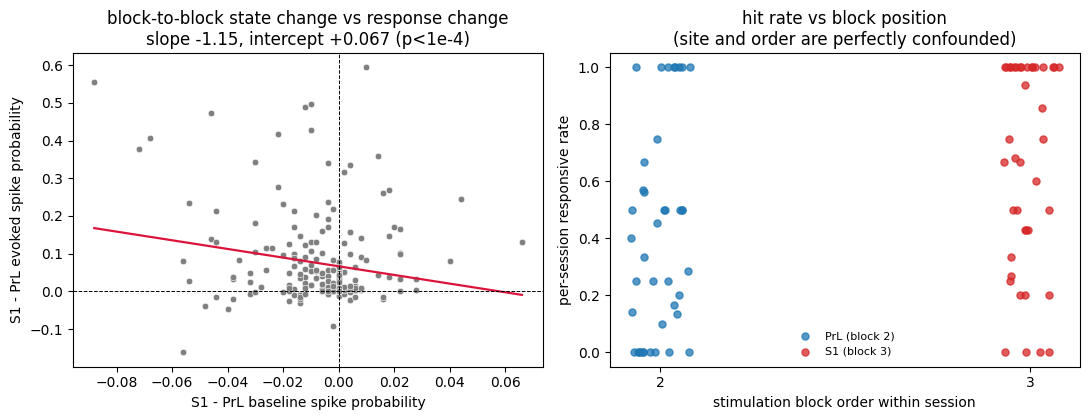

In [11]:
# How much of the S1 > PrL response difference tracks the within-unit change in
# spontaneous activity between the two blocks?
import statsmodels.api as sm

d = paired[['evoked_prob_PrL', 'evoked_prob_S1', 'baseline_prob_PrL', 'baseline_prob_S1']].dropna()
d_evoked = (d.evoked_prob_S1 - d.evoked_prob_PrL).to_numpy()
d_base = (d.baseline_prob_S1 - d.baseline_prob_PrL).to_numpy()
rho, p_rho = stats.spearmanr(d_base, d_evoked)
fit = sm.OLS(d_evoked, sm.add_constant(d_base)).fit()
print(f'n = {len(d)} units')
print(f'Spearman(delta baseline, delta evoked) = {rho:.3f}, {fmt_p(p_rho)}')
print(f'delta evoked ~ delta baseline: slope {fit.params[1]:+.3f} ({fmt_p(fit.pvalues[1])}), '
      f'R2 = {fit.rsquared:.3f}')
ci_intercept = np.asarray(fit.conf_int())[0]
print(f'intercept (S1 - PrL evoked at zero baseline change) = {fit.params[0]:+.4f} '
      f'[{ci_intercept[0]:+.4f}, {ci_intercept[1]:+.4f}] {fmt_p(fit.pvalues[0])}')
print('-> the intercept is the site difference after removing the part that scales with the '
      'block-to-block change in spontaneous activity. It does NOT remove a block effect that '
      'acts only on evoked responses.')

fig, axs = plt.subplots(1, 2, figsize=(11, 4.3))
ax = axs[0]
ax.scatter(d_base, d_evoked, s=22, color='gray', edgecolor='white', linewidth=0.4)
xs = np.linspace(d_base.min(), d_base.max(), 50)
ax.plot(xs, fit.params[0] + fit.params[1]*xs, color='crimson', linewidth=1.6)
ax.axhline(0, color='k', linewidth=0.7, linestyle='--')
ax.axvline(0, color='k', linewidth=0.7, linestyle='--')
ax.set_xlabel('S1 - PrL baseline spike probability')
ax.set_ylabel('S1 - PrL evoked spike probability')
ax.set_title(f'block-to-block state change vs response change\nslope {fit.params[1]:+.2f}, '
             f'intercept {fit.params[0]:+.3f} ({fmt_p(fit.pvalues[0])})')

ax = axs[1]
bo = block_order.copy()
bo['site_short'] = bo.site.str.replace('surface_', '', regex=False)
resp = (long.groupby(['session', 'focus'])[GROUP_CRITERION].mean()
        .rename('rate').reset_index()
        .rename(columns={'focus': 'site_short'}))
bo2 = bo.merge(resp, on=['session', 'site_short'], how='inner')
for site_short, sub in bo2.groupby('site_short'):
    ax.scatter(sub.block_order + np.random.uniform(-0.08, 0.08, len(sub)), sub.rate, s=26,
               color=FOCUS_COLORS.get(site_short, 'gray'), alpha=0.75,
               label=f'{site_short} (block {int(sub.block_order.median())})')
ax.set_xlabel('stimulation block order within session')
ax.set_ylabel(f'per-session {GROUP_CRITERION} rate')
ax.set_xticks(sorted(bo2.block_order.unique()))
ax.set_title('hit rate vs block position\n(site and order are perfectly confounded)')
ax.legend(frameon=False, fontsize=8)
plt.tight_layout()
savefig(fig, 'block_order_confound')
plt.show()

## 5. Paired hit rates: PrL vs S1

With both sites tested in every unit, the correct test is McNemar on the discordant
pairs. The unpaired two-proportion test is also shown for comparison, since it is what a
non-paired design would have reported.

In [12]:
hit_rows = []
for crit in CRITERIA:
    p = paired[f'{crit}_PrL'].astype(bool).to_numpy()
    s = paired[f'{crit}_S1'].astype(bool).to_numpy()
    both, p_only, s_only, neither = int((p & s).sum()), int((p & ~s).sum()), int((s & ~p).sum()), int((~p & ~s).sum())
    table = np.array([[both, p_only], [s_only, neither]])
    mc = mcnemar(table, exact=True)
    unpaired = binary_shift_X_vs_Y(p.astype(int), s.astype(int),
                                   permutations=N_PERM_SHIFT, seed=SEED)
    hit_rows.append({
        'criterion': crit, 'n_units': len(paired),
        'n_PrL': int(p.sum()), 'n_S1': int(s.sum()),
        'rate_PrL': p.mean(), 'rate_S1': s.mean(),
        'both': both, 'PrL_only': p_only, 'S1_only': s_only, 'neither': neither,
        'p_mcnemar_exact': float(mc.pvalue),
        'odds_ratio_discordant': (p_only / s_only) if s_only else np.inf,
        'p_unpaired_fisher': unpaired['p_value_fisher'],
    })
hit_rates = pd.DataFrame(hit_rows)
hit_rates['p_mcnemar_fdr'] = multipletests(hit_rates.p_mcnemar_exact, method='fdr_bh')[1]
hit_rates.round(4)

/opt/conda/lib/python3.12/site-packages/statsmodels/stats/weightstats.py:792: RuntimeWarning: invalid value encountered in scalar divide
  zstat = value / std


,criterion,n_units,n_PrL,n_S1,rate_PrL,rate_S1,both,PrL_only,S1_only,neither,p_mcnemar_exact,odds_ratio_discordant,p_unpaired_fisher,p_mcnemar_fdr
0,responsive,209,79,135,0.3780,0.6459,75,4,60,70,0.0000,0.0667,0.0000,0.0000
1,sharp,209,8,22,0.0383,0.1053,4,4,18,183,0.0043,0.2222,0.0126,0.0065
2,collision_confirmed,209,0,0,0.0000,0.0000,0,0,0,209,1.0000,inf,1.0000,1.0000
3,reg_antidromic,209,85,120,0.4067,0.5742,82,3,38,86,0.0000,0.0789,0.0009,0.0000
4,reg_sharp_antidromic,209,16,36,0.0766,0.1722,8,8,28,165,0.0012,0.2857,0.0045,0.0024
5,reg_antidromic_collision,209,21,23,0.1005,0.1100,17,4,6,182,0.7539,0.6667,0.8736,0.9047


saved /root/capsule/scratch/results/manuscript/figures/F_antidromic_DRN/hit_rates_PrL_vs_S1


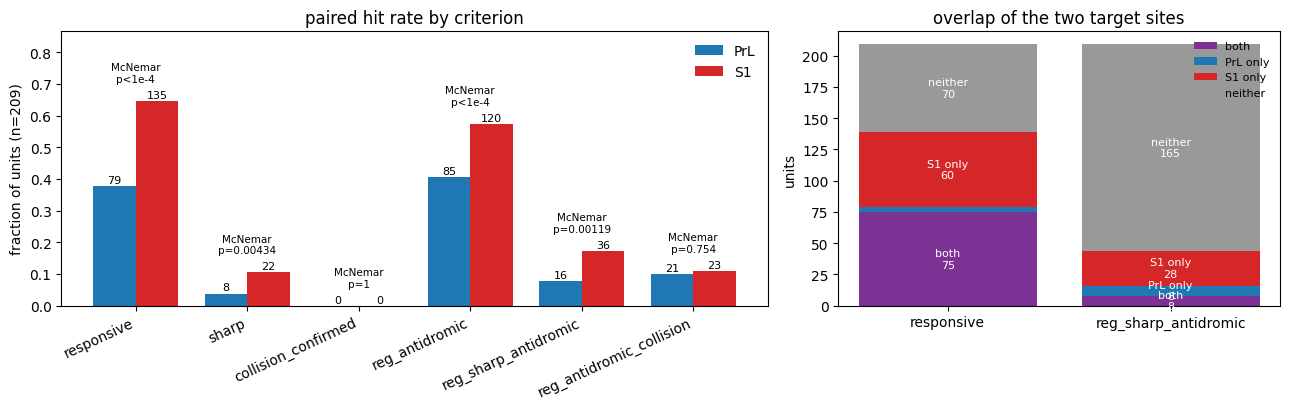

In [13]:
fig, axs = plt.subplots(1, 2, figsize=(13, 4.2), gridspec_kw={'width_ratios': [1.6, 1]})

x = np.arange(len(hit_rates))
w = 0.38
ax = axs[0]
ax.bar(x - w/2, hit_rates.rate_PrL, w, color=FOCUS_COLORS['PrL'], label='PrL')
ax.bar(x + w/2, hit_rates.rate_S1, w, color=FOCUS_COLORS['S1'], label='S1')
for i, r in hit_rates.iterrows():
    ax.text(i - w/2, r.rate_PrL + 0.01, str(r.n_PrL), ha='center', fontsize=8)
    ax.text(i + w/2, r.rate_S1 + 0.01, str(r.n_S1), ha='center', fontsize=8)
    y = max(r.rate_PrL, r.rate_S1) + 0.06
    ax.text(i, y, f'McNemar\n{fmt_p(r.p_mcnemar_exact)}', ha='center', fontsize=7.5)
ax.set_xticks(x)
ax.set_xticklabels(hit_rates.criterion, rotation=25, ha='right')
ax.set_ylabel(f'fraction of units (n={len(paired)})')
ax.set_ylim(0, max(hit_rates[['rate_PrL', 'rate_S1']].to_numpy().max() + 0.22, 0.3))
ax.set_title('paired hit rate by criterion')
ax.legend(frameon=False)

ax = axs[1]
for i, crit in enumerate([GROUP_CRITERION, SECONDARY_CRITERION]):
    r = hit_rates.set_index('criterion').loc[crit]
    bottom = 0
    for g, c in zip(GROUP_ORDER, [GROUP_COLORS[g] for g in GROUP_ORDER]):
        key = {'both': 'both', 'PrL only': 'PrL_only', 'S1 only': 'S1_only', 'neither': 'neither'}[g]
        ax.bar(i, r[key], bottom=bottom, color=c, label=g if i == 0 else None)
        if r[key] > 4:
            ax.text(i, bottom + r[key]/2, f'{g}\n{int(r[key])}', ha='center', va='center',
                    fontsize=8, color='white')
        bottom += r[key]
ax.set_xticks([0, 1])
ax.set_xticklabels([GROUP_CRITERION, SECONDARY_CRITERION])
ax.set_ylabel('units')
ax.set_title('overlap of the two target sites')
ax.legend(frameon=False, fontsize=8, loc='upper right')
plt.tight_layout()
savefig(fig, 'hit_rates_PrL_vs_S1')
plt.show()

P(spike in 5-25 ms | pulse):
  PrL 0.1105  S1 0.1852  Wilcoxon p<1e-4  n=208
baseline-subtracted:
  PrL +0.0598  S1 +0.1415  Wilcoxon p<1e-4


saved /root/capsule/scratch/results/manuscript/figures/F_antidromic_DRN/evoked_probability_PrL_vs_S1


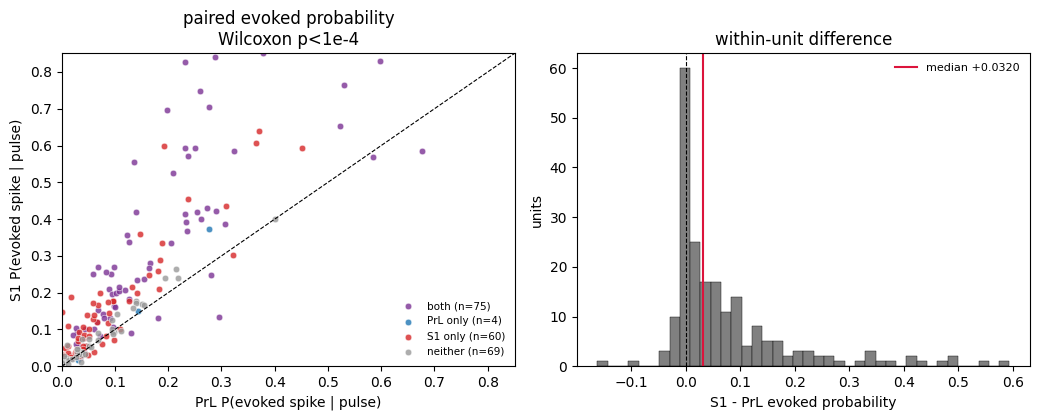

In [14]:
# Effect size rather than significance: paired evoked-probability difference.
d = paired[['evoked_prob_PrL', 'evoked_prob_S1', 'delta_prob_PrL', 'delta_prob_S1', 'group']].dropna(
    subset=['evoked_prob_PrL', 'evoked_prob_S1'])
w_ev = stats.wilcoxon(d.evoked_prob_PrL, d.evoked_prob_S1)
w_dl = stats.wilcoxon(d.delta_prob_PrL, d.delta_prob_S1)
print(f'P(spike in {EVOKED_WINDOW[0]*1e3:.0f}-{EVOKED_WINDOW[1]*1e3:.0f} ms | pulse):')
print(f'  PrL {d.evoked_prob_PrL.mean():.4f}  S1 {d.evoked_prob_S1.mean():.4f}  '
      f'Wilcoxon {fmt_p(w_ev.pvalue)}  n={len(d)}')
print(f'baseline-subtracted:')
print(f'  PrL {d.delta_prob_PrL.mean():+.4f}  S1 {d.delta_prob_S1.mean():+.4f}  '
      f'Wilcoxon {fmt_p(w_dl.pvalue)}')

fig, axs = plt.subplots(1, 2, figsize=(10.5, 4.3))
ax = axs[0]
lim = np.nanpercentile(np.r_[d.evoked_prob_PrL, d.evoked_prob_S1], 99.5)
for g in GROUP_ORDER:
    m = d.group == g
    ax.scatter(d.loc[m, 'evoked_prob_PrL'], d.loc[m, 'evoked_prob_S1'], s=22,
               color=GROUP_COLORS[g], label=f'{g} (n={int(m.sum())})', alpha=0.8,
               edgecolor='white', linewidth=0.4)
ax.plot([0, lim], [0, lim], 'k--', linewidth=0.8)
ax.set_xlabel('PrL P(evoked spike | pulse)')
ax.set_ylabel('S1 P(evoked spike | pulse)')
ax.set_xlim(0, lim); ax.set_ylim(0, lim)
ax.set_title(f'paired evoked probability\nWilcoxon {fmt_p(w_ev.pvalue)}')
ax.legend(frameon=False, fontsize=7.5)

ax = axs[1]
diff = (d.evoked_prob_S1 - d.evoked_prob_PrL).to_numpy()
ax.hist(diff, bins=40, color='gray', edgecolor='k', linewidth=0.3)
ax.axvline(0, color='k', linestyle='--', linewidth=0.8)
ax.axvline(np.median(diff), color='crimson', linewidth=1.5,
           label=f'median {np.median(diff):+.4f}')
ax.set_xlabel('S1 - PrL evoked probability')
ax.set_ylabel('units')
ax.set_title('within-unit difference')
ax.legend(frameon=False, fontsize=8)
plt.tight_layout()
savefig(fig, 'evoked_probability_PrL_vs_S1')
plt.show()

## 6. Session- and animal-level control

Units from one session share a probe insertion, a fiber placement and an animal, so
unit-level n is pseudoreplicated. Each session (and each animal) is re-tested as a single
replicate: paired hit rates per session, then a signed-rank / sign test on the sessions.

In [15]:
def cluster_level_test(criterion, by='session'):
    g = (long.groupby([by, 'focus'])[criterion].mean().unstack('focus').dropna())
    if len(g) < 3:
        return None, g
    diff = (g['PrL'] - g['S1']).to_numpy()
    nz = diff[diff != 0]
    res = {
        'criterion': criterion, 'level': by, 'n_clusters': len(g),
        'mean_rate_PrL': g['PrL'].mean(), 'mean_rate_S1': g['S1'].mean(),
        'median_diff_PrL_minus_S1': float(np.median(diff)),
        'n_PrL_higher': int((diff > 0).sum()), 'n_S1_higher': int((diff < 0).sum()),
        'n_tied': int((diff == 0).sum()),
    }
    res['p_wilcoxon'] = float(stats.wilcoxon(g['PrL'], g['S1']).pvalue) if len(nz) else np.nan
    res['p_sign'] = float(stats.binomtest(int((diff > 0).sum()), len(nz), 0.5).pvalue) if len(nz) else np.nan
    return res, g

cluster_rows, cluster_frames = [], {}
for crit in CRITERIA:
    for by in ['session', 'subject']:
        res, g = cluster_level_test(crit, by)
        cluster_frames[(crit, by)] = g
        if res is not None:
            cluster_rows.append(res)
cluster_stats = pd.DataFrame(cluster_rows)
cluster_stats.round(4)

,criterion,level,n_clusters,mean_rate_PrL,mean_rate_S1,median_diff_PrL_minus_S1,n_PrL_higher,n_S1_higher,n_tied,p_wilcoxon,p_sign
0,responsive,session,40,0.4129,0.6536,-0.2136,1,27,12,0.0001,0.0000
1,responsive,subject,15,0.4214,0.6725,-0.2632,0,13,2,0.0015,0.0002
2,sharp,session,40,0.0246,0.0796,0.0000,2,10,28,0.0592,0.0386
3,sharp,subject,15,0.0207,0.1012,0.0000,1,7,7,0.0355,0.0703
4,collision_confirmed,session,40,0.0000,0.0000,0.0000,0,0,40,NaN,NaN
5,collision_confirmed,subject,15,0.0000,0.0000,0.0000,0,0,15,NaN,NaN
6,reg_antidromic,session,40,0.4406,0.5586,-0.0312,0,20,20,0.0001,0.0000
7,reg_antidromic,subject,15,0.4279,0.5904,-0.1905,0,14,1,0.0010,0.0001
8,reg_sharp_antidromic,session,40,0.0627,0.1614,0.0000,5,12,23,0.0645,0.1435
9,reg_sharp_antidromic,subject,15,0.0545,0.2095,-0.0286,2,8,5,0.0593,0.1094


saved /root/capsule/scratch/results/manuscript/figures/F_antidromic_DRN/session_level_hit_rates


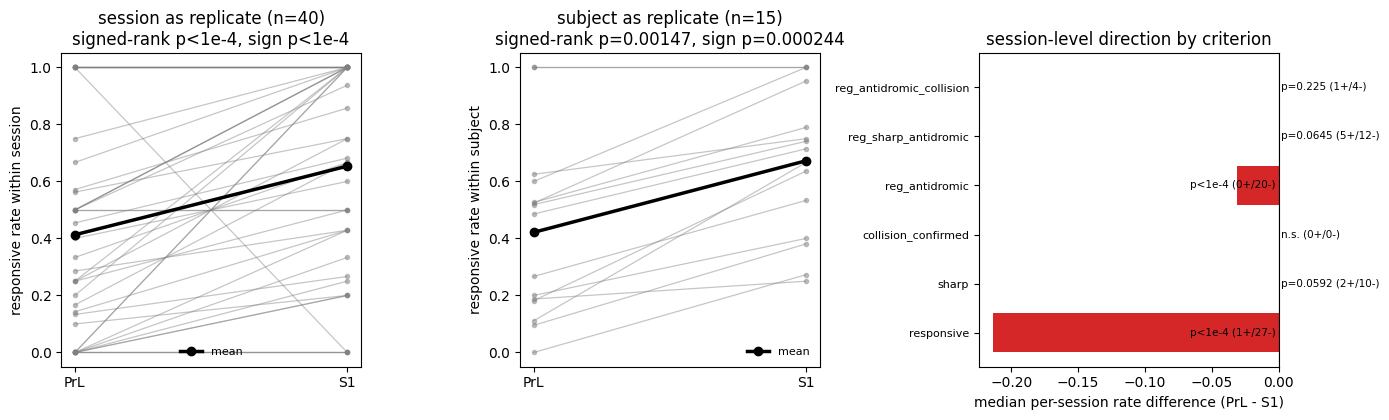

In [16]:
fig, axs = plt.subplots(1, 3, figsize=(14, 4.3))
crit = GROUP_CRITERION
for ax, by in zip(axs[:2], ['session', 'subject']):
    g = cluster_frames[(crit, by)]
    for _, row in g.iterrows():
        ax.plot([0, 1], [row['PrL'], row['S1']], color='gray', alpha=0.45, linewidth=0.9,
                marker='o', markersize=3)
    ax.plot([0, 1], [g['PrL'].mean(), g['S1'].mean()], color='k', linewidth=2.5, marker='o',
            label='mean')
    r = cluster_stats.query('criterion == @crit and level == @by').iloc[0]
    ax.set_xticks([0, 1]); ax.set_xticklabels(['PrL', 'S1'])
    ax.set_ylabel(f'{crit} rate within {by}')
    ax.set_title(f'{by} as replicate (n={int(r.n_clusters)})\n'
                 f'signed-rank {fmt_p(r.p_wilcoxon)}, sign {fmt_p(r.p_sign)}')
    ax.legend(frameon=False, fontsize=8)

ax = axs[2]
sub = cluster_stats.query('level == "session"')
y = np.arange(len(sub))
ax.barh(y, sub.median_diff_PrL_minus_S1, color=['#1f77b4' if v > 0 else '#d62728'
                                               for v in sub.median_diff_PrL_minus_S1])
for i, r in enumerate(sub.itertuples()):
    ax.text(0.002 if r.median_diff_PrL_minus_S1 >= 0 else -0.002, i,
            f'{fmt_p(r.p_wilcoxon)} ({r.n_PrL_higher}+/{r.n_S1_higher}-)',
            va='center', ha='left' if r.median_diff_PrL_minus_S1 >= 0 else 'right', fontsize=7.5)
ax.axvline(0, color='k', linewidth=0.8)
ax.set_yticks(y); ax.set_yticklabels(sub.criterion, fontsize=8)
ax.set_xlabel('median per-session rate difference (PrL - S1)')
ax.set_title('session-level direction by criterion')
plt.tight_layout()
savefig(fig, 'session_level_hit_rates')
plt.show()

## 7. Response timing and collision behaviour

Latency and jitter are only defined where the first-spike histogram had enough spikes, so
these are computed on the units where the metric exists for both sites (paired) and,
separately, for all units passing each criterion at each site (unpaired).

In [17]:
timing_rows = []
for metric, label in [('antidromic_latency', 'first-spike peak latency (s)'),
                      ('median_first_spike_latency', 'median first-spike latency (s)'),
                      ('jitter', 'jitter / FWHM (s)'),
                      ('pre_boundary_prob', 'P(antidromic spike) outside the collision zone'),
                      ('post_boundary_prob', 'P(antidromic spike) inside the collision zone')]:
    d = paired[[f'{metric}_PrL', f'{metric}_S1']].dropna()
    if len(d) < 3:
        continue
    wl = stats.wilcoxon(d[f'{metric}_PrL'], d[f'{metric}_S1'])
    timing_rows.append({
        'metric': metric, 'label': label, 'n_paired': len(d),
        'mean_PrL': d[f'{metric}_PrL'].mean(), 'mean_S1': d[f'{metric}_S1'].mean(),
        'median_PrL': d[f'{metric}_PrL'].median(), 'median_S1': d[f'{metric}_S1'].median(),
        'p_wilcoxon_paired': float(wl.pvalue),
    })
timing_stats = pd.DataFrame(timing_rows)
timing_stats['p_fdr'] = multipletests(timing_stats.p_wilcoxon_paired, method='fdr_bh')[1]
timing_stats.round(5)

,metric,label,n_paired,mean_PrL,mean_S1,median_PrL,median_S1,p_wilcoxon_paired,p_fdr
0,antidromic_latency,first-spike peak latency (s),180,0.01829,0.01486,0.01650,0.01300,0.00133,0.00133
1,median_first_spike_latency,median first-spike latency (s),180,0.04634,0.03229,0.04539,0.02978,0.00000,0.00000
2,jitter,jitter / FWHM (s),180,0.05252,0.03467,0.05775,0.02175,0.00000,0.00000
3,pre_boundary_prob,P(antidromic spike) outside the collision zone,165,0.04674,0.09003,0.01786,0.03846,0.00000,0.00000
4,post_boundary_prob,P(antidromic spike) inside the collision zone,82,0.01393,0.05345,0.00000,0.00000,0.00000,0.00000


saved /root/capsule/scratch/results/manuscript/figures/F_antidromic_DRN/timing_and_collision


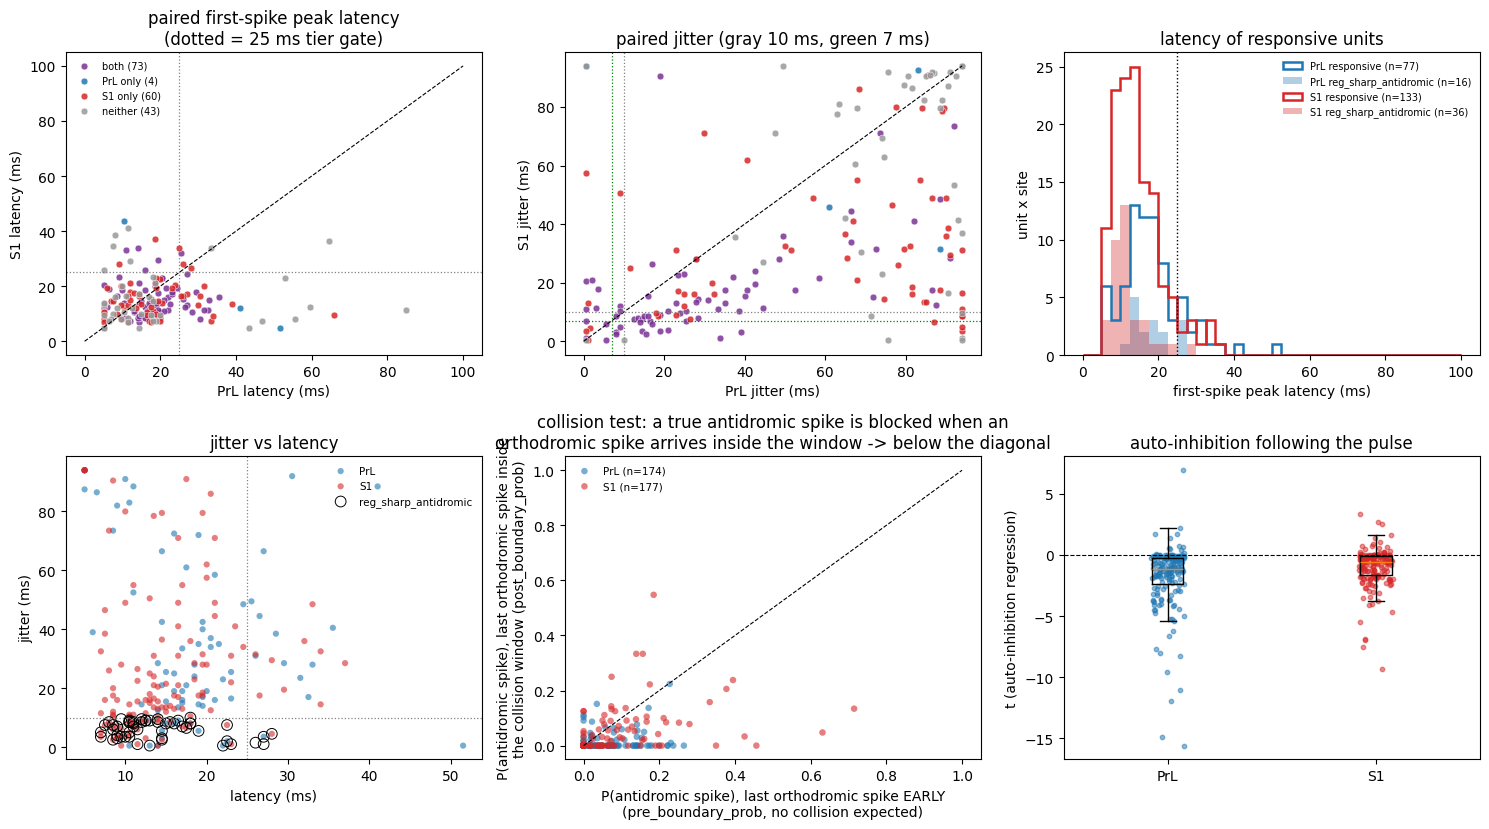

In [18]:
fig, axs = plt.subplots(2, 3, figsize=(15, 8.4))

# (a) latency, paired
ax = axs[0, 0]
d = paired[['antidromic_latency_PrL', 'antidromic_latency_S1', 'group']].dropna(
    subset=['antidromic_latency_PrL', 'antidromic_latency_S1'])
for g in GROUP_ORDER:
    m = d.group == g
    ax.scatter(d.loc[m, 'antidromic_latency_PrL']*1e3, d.loc[m, 'antidromic_latency_S1']*1e3,
               s=24, color=GROUP_COLORS[g], alpha=0.85, edgecolor='white', linewidth=0.4,
               label=f'{g} ({int(m.sum())})')
ax.plot([0, 100], [0, 100], 'k--', linewidth=0.8)
for v in [TIER_MAX_LATENCY*1e3]:
    ax.axvline(v, color='gray', linestyle=':', linewidth=0.9)
    ax.axhline(v, color='gray', linestyle=':', linewidth=0.9)
ax.set_xlabel('PrL latency (ms)'); ax.set_ylabel('S1 latency (ms)')
ax.set_title('paired first-spike peak latency\n(dotted = %g ms tier gate)' % (TIER_MAX_LATENCY*1e3))
ax.legend(frameon=False, fontsize=7)

# (b) jitter, paired
ax = axs[0, 1]
d = paired[['jitter_PrL', 'jitter_S1', 'group']].dropna(subset=['jitter_PrL', 'jitter_S1'])
for g in GROUP_ORDER:
    m = d.group == g
    ax.scatter(d.loc[m, 'jitter_PrL']*1e3, d.loc[m, 'jitter_S1']*1e3, s=24,
               color=GROUP_COLORS[g], alpha=0.85, edgecolor='white', linewidth=0.4)
mx = np.nanpercentile(np.r_[d.jitter_PrL, d.jitter_S1]*1e3, 99)
ax.plot([0, mx], [0, mx], 'k--', linewidth=0.8)
ax.axvline(REG_JITTER*1e3, color='gray', linestyle=':', linewidth=0.9)
ax.axhline(REG_JITTER*1e3, color='gray', linestyle=':', linewidth=0.9)
ax.axvline(TIER_JITTER*1e3, color='green', linestyle=':', linewidth=0.9)
ax.axhline(TIER_JITTER*1e3, color='green', linestyle=':', linewidth=0.9)
ax.set_xlabel('PrL jitter (ms)'); ax.set_ylabel('S1 jitter (ms)')
ax.set_title('paired jitter (gray %g ms, green %g ms)' % (REG_JITTER*1e3, TIER_JITTER*1e3))

# (c) latency distributions of passing units
ax = axs[0, 2]
bins = np.linspace(0, 100, 41)
for focus in focuses:
    v = long.loc[(long.focus == focus) & long[GROUP_CRITERION], 'antidromic_latency'].dropna()*1e3
    ax.hist(v, bins=bins, histtype='step', linewidth=1.8, color=FOCUS_COLORS[focus],
            label=f'{focus} {GROUP_CRITERION} (n={len(v)})')
    vs = long.loc[(long.focus == focus) & long[SECONDARY_CRITERION], 'antidromic_latency'].dropna()*1e3
    ax.hist(vs, bins=bins, color=FOCUS_COLORS[focus], alpha=0.35,
            label=f'{focus} {SECONDARY_CRITERION} (n={len(vs)})')
ax.axvline(TIER_MAX_LATENCY*1e3, color='k', linestyle=':', linewidth=1)
ax.set_xlabel('first-spike peak latency (ms)'); ax.set_ylabel('unit x site')
ax.set_title('latency of responsive units')
ax.legend(frameon=False, fontsize=7)

# (d) jitter vs latency, both sites
ax = axs[1, 0]
for focus in focuses:
    m = (long.focus == focus) & long[GROUP_CRITERION]
    ax.scatter(long.loc[m, 'antidromic_latency']*1e3, long.loc[m, 'jitter']*1e3, s=20,
               color=FOCUS_COLORS[focus], alpha=0.6, edgecolor='none', label=focus)
m = long[SECONDARY_CRITERION]
ax.scatter(long.loc[m, 'antidromic_latency']*1e3, long.loc[m, 'jitter']*1e3, s=60,
           facecolor='none', edgecolor='k', linewidth=0.7, label=SECONDARY_CRITERION)
ax.axhline(REG_JITTER*1e3, color='gray', linestyle=':', linewidth=0.9)
ax.axvline(TIER_MAX_LATENCY*1e3, color='gray', linestyle=':', linewidth=0.9)
ax.set_xlabel('latency (ms)'); ax.set_ylabel('jitter (ms)')
ax.set_title('jitter vs latency')
ax.legend(frameon=False, fontsize=7.5)

# (e) collision behaviour
ax = axs[1, 1]
for focus in focuses:
    m = (long.focus == focus) & long['pre_boundary_prob'].notna()
    ax.scatter(long.loc[m, 'pre_boundary_prob'], long.loc[m, 'post_boundary_prob'], s=22,
               color=FOCUS_COLORS[focus], alpha=0.6, edgecolor='none',
               label=f'{focus} (n={int(m.sum())})')
ax.plot([0, 1], [0, 1], 'k--', linewidth=0.8)
ax.set_xlabel('P(antidromic spike), last orthodromic spike EARLY\n(pre_boundary_prob, no collision expected)')
ax.set_ylabel('P(antidromic spike), last orthodromic spike inside\nthe collision window (post_boundary_prob)')
ax.set_title('collision test: a true antidromic spike is blocked when an\northodromic spike arrives inside the window -> below the diagonal')
ax.legend(frameon=False, fontsize=7.5)

# (f) auto-inhibition (soma site control)
ax = axs[1, 2]
tvals = {focus: long.loc[long.focus == focus, 't_auto_inhi'].dropna() for focus in focuses}
ax.boxplot([tvals[f] for f in focuses], tick_labels=focuses, showfliers=False)
for i, focus in enumerate(focuses, start=1):
    v = tvals[focus]
    ax.scatter(np.full(len(v), i) + np.random.uniform(-0.08, 0.08, len(v)), v, s=10,
               color=FOCUS_COLORS[focus], alpha=0.5)
ax.axhline(0, color='k', linestyle='--', linewidth=0.8)
ax.set_ylabel('t (auto-inhibition regression)')
ax.set_title('auto-inhibition following the pulse')
plt.tight_layout()
savefig(fig, 'timing_and_collision')
plt.show()

## 8. Anatomy: where in the DR do PrL- and S1-responsive units sit?

Coordinates are bregma-relative LPS mm with |ML| mirrored, overlaid on the DR mesh.
Because the comparison groups are defined per site but drawn from the same units, each
site is tested as pass-vs-fail within that site (Welch + label permutation per axis), and
the pass flag is additionally tested for any spatial structure at all with the
kNN/linear-trend permutation summary.

In [19]:
ml, ap, dv = 0, 1, 2
planes = {'sag': [ap, dv], 'hor': [ml, ap], 'cor': [ml, dv]}
axis_names = {ml: '|ML| from midline (mm)' if MIRROR_ML else 'ML (mm)',
              ap: 'AP from bregma (mm)', dv: 'DV from bregma (mm)'}

mesh = load_mesh(mesh_file)
mesh_vertices_mm = np.asarray(mesh.vertices, dtype=float).copy()
if MIRROR_ML:
    mesh_vertices_mm[:, ml] = np.abs(mesh_vertices_mm[:, ml])
mesh_contours = {name: project_to_plane(mesh_vertices_mm, axes, pitch=0.02, margin=0.5)
                 for name, axes in planes.items()}

coords = paired[['ml', 'ap', 'dv']].to_numpy(float)
plot_margin = 0.3
plot_limits = {}
for name, axes_ in planes.items():
    xdim, ydim = axes_
    xs = np.concatenate([coords[:, xdim], mesh_vertices_mm[:, xdim]])
    ys = np.concatenate([coords[:, ydim], mesh_vertices_mm[:, ydim]])
    plot_limits[name] = {'xlim': (np.nanmin(xs)-plot_margin, np.nanmax(xs)+plot_margin),
                         'ylim': (np.nanmin(ys)-plot_margin, np.nanmax(ys)+plot_margin)}

print('units with finite coordinates:', int(np.isfinite(coords).all(axis=1).sum()), '/', len(coords))
for i, nm in zip([ml, ap, dv], ['|ML|', 'AP', 'DV']):
    print(f'  {nm}: units {np.nanmin(coords[:, i]):.2f}..{np.nanmax(coords[:, i]):.2f}  '
          f'mesh {mesh_vertices_mm[:, i].min():.2f}..{mesh_vertices_mm[:, i].max():.2f}')

units with finite coordinates: 209 / 209
  |ML|: units 0.00..0.66  mesh 0.00..0.16
  AP: units 3.76..4.86  mesh 3.99..4.96
  DV: units -4.87..-1.76  mesh -4.19..-2.76


saved /root/capsule/scratch/results/manuscript/figures/F_antidromic_DRN/anatomy_groups_3planes


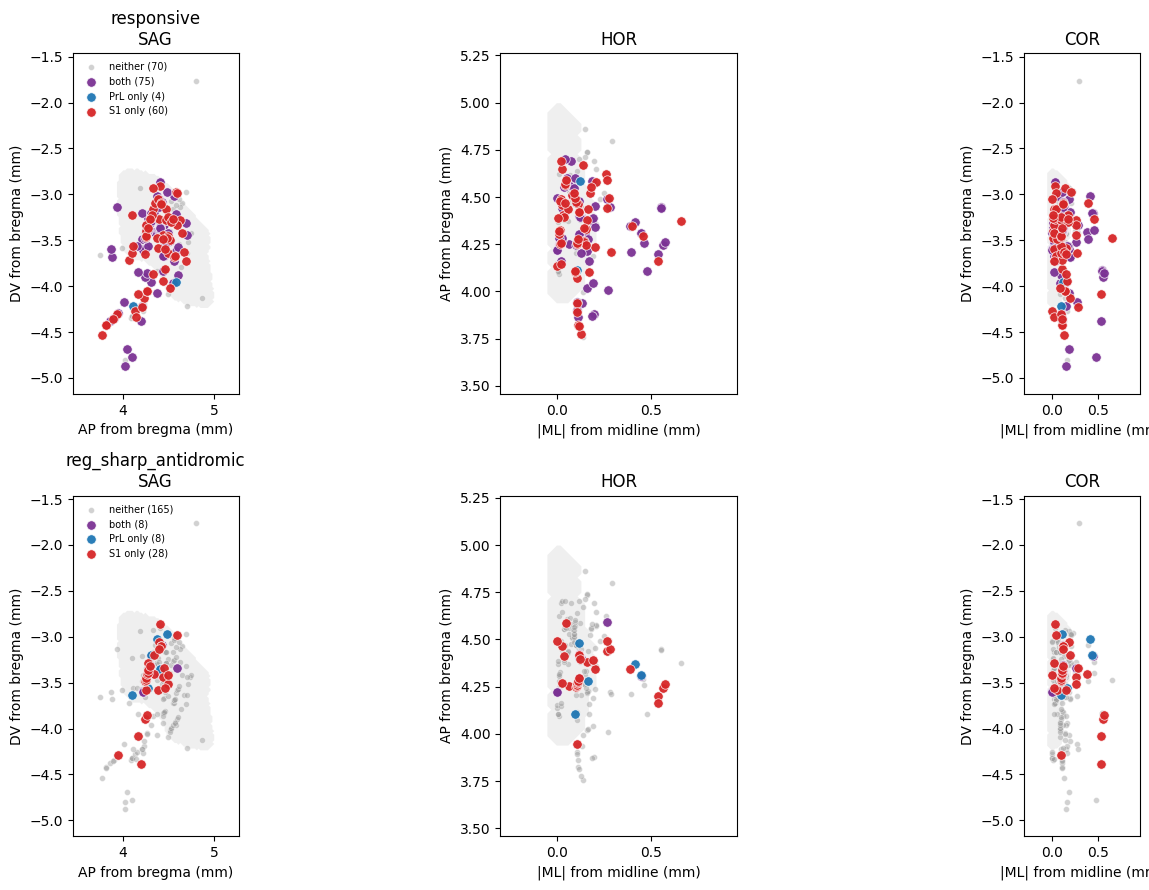

In [20]:
fig, axes_g = plt.subplots(2, 3, figsize=(15, 9))
for row, crit in enumerate([GROUP_CRITERION, SECONDARY_CRITERION]):
    groups = paired[f'group_{crit}']
    for col, (plane, pa) in enumerate(planes.items()):
        ax = axes_g[row, col]
        for contour in mesh_contours[plane]:
            ax.fill(contour[:, 0], contour[:, 1], color='lightgray', alpha=0.35,
                    linewidth=0, zorder=0)
        for g in ['neither', 'both', 'PrL only', 'S1 only']:
            m = (groups == g).to_numpy()
            if not m.any():
                continue
            ax.scatter(coords[m, pa[0]], coords[m, pa[1]],
                       s=18 if g == 'neither' else 46,
                       color=GROUP_COLORS[g], alpha=0.45 if g == 'neither' else 0.95,
                       edgecolor='white', linewidth=0.5,
                       zorder=1 if g == 'neither' else 3,
                       label=f'{g} ({int(m.sum())})')
        ax.set_xlabel(axis_names[pa[0]]); ax.set_ylabel(axis_names[pa[1]])
        ax.set_aspect('equal')
        ax.set_xlim(*plot_limits[plane]['xlim']); ax.set_ylim(*plot_limits[plane]['ylim'])
        if col == 0:
            ax.set_title(f'{crit}\n{plane.upper()}')
            ax.legend(frameon=False, fontsize=7, loc='upper left')
        else:
            ax.set_title(plane.upper())
plt.tight_layout()
savefig(fig, 'anatomy_groups_3planes')
plt.show()

In [21]:
# Per-axis pass-vs-fail location tests, within site.
axis_rows = []
for crit in CRITERIA:
    for focus in focuses:
        flag = paired[f'{crit}_{focus}'].astype(bool).to_numpy()
        if flag.sum() < 3 or (~flag).sum() < 3:
            continue
        for i, nm in zip([ml, ap, dv], ['ml', 'ap', 'dv']):
            v = coords[:, i]
            try:
                res = welch_shift_X_vs_Y(v[flag], v[~flag], permutations=N_PERM_SHIFT,
                                         seed=SEED, n_boot=2000)
            except ValueError:
                continue
            axis_rows.append({
                'criterion': crit, 'focus': focus, 'axis': nm,
                'n_pass': res['n_X'], 'n_fail': res['n_Y'],
                'mean_pass': res['mean_X'], 'mean_fail': res['mean_Y'],
                'diff': res['mean_diff_X_minus_Y'],
                'ci_low': res['mean_diff_bootstrap_CI95'][0],
                'ci_high': res['mean_diff_bootstrap_CI95'][1],
                'cohens_d': res['cohens_d'],
                'p_perm': res['p_value_permutation'],
            })
axis_stats = pd.DataFrame(axis_rows)
axis_stats['p_fdr'] = multipletests(axis_stats.p_perm, method='fdr_bh')[1]
axis_stats.sort_values('p_perm').round(4).head(20)

,criterion,focus,axis,n_pass,n_fail,mean_pass,mean_fail,diff,ci_low,ci_high,cohens_d,p_perm,p_fdr
4,responsive,S1,ap,135,74,4.3263,4.4313,-0.1049,-0.1626,-0.0500,-0.5193,0.0008,0.0240
16,reg_antidromic,S1,ap,120,89,4.3240,4.4167,-0.0928,-0.1469,-0.0384,-0.4568,0.0016,0.0240
20,reg_sharp_antidromic,PrL,dv,16,193,-3.3385,-3.5758,0.2373,0.1225,0.3514,0.5462,0.0030,0.0300
13,reg_antidromic,PrL,ap,85,124,4.3173,4.3951,-0.0778,-0.1324,-0.0230,-0.3802,0.0070,0.0456
3,responsive,S1,ml,135,74,0.1505,0.1107,0.0398,0.0113,0.0689,0.3224,0.0076,0.0456
1,responsive,PrL,ap,79,130,4.3182,4.3910,-0.0728,-0.1287,-0.0167,-0.3547,0.0108,0.0540
11,sharp,S1,dv,22,187,-3.3870,-3.5777,0.1907,0.0454,0.3242,0.4384,0.0140,0.0600
15,reg_antidromic,S1,ml,120,89,0.1526,0.1146,0.0380,0.0078,0.0690,0.3078,0.0160,0.0600
12,reg_antidromic,PrL,ml,85,124,0.1626,0.1185,0.0442,0.0101,0.0815,0.3592,0.0184,0.0613
23,reg_sharp_antidromic,S1,dv,36,173,-3.4406,-3.5820,0.1414,0.0060,0.2651,0.3246,0.0392,0.1176


saved /root/capsule/scratch/results/manuscript/figures/F_antidromic_DRN/anatomy_axis_shift


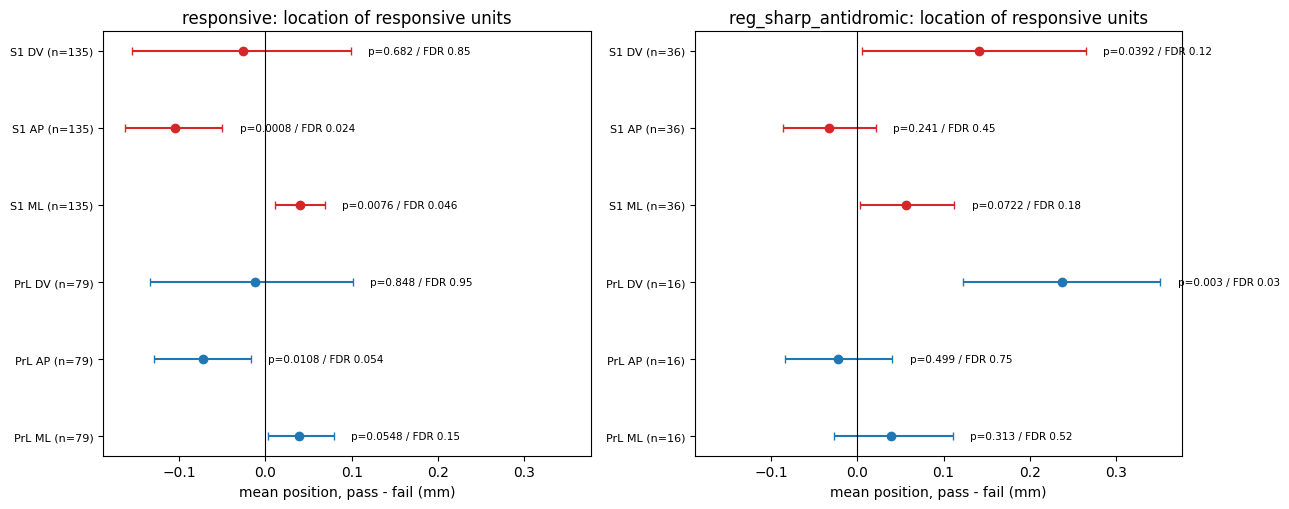

In [22]:
fig, axs = plt.subplots(1, 2, figsize=(13, 5.2), sharex=True)
for ax, crit in zip(axs, [GROUP_CRITERION, SECONDARY_CRITERION]):
    sub = axis_stats.query('criterion == @crit')
    labels, y = [], 0
    for focus in focuses:
        for nm in ['ml', 'ap', 'dv']:
            r = sub.query('focus == @focus and axis == @nm')
            if r.empty:
                continue
            r = r.iloc[0]
            ax.errorbar(r['diff'], y, xerr=[[r['diff']-r.ci_low], [r.ci_high-r['diff']]],
                        fmt='o', color=FOCUS_COLORS[focus], capsize=3)
            ax.text(r.ci_high + 0.02, y, f"{fmt_p(r.p_perm)} / FDR {r.p_fdr:.2g}",
                    va='center', fontsize=7.5)
            labels.append(f'{focus} {nm.upper()} (n={int(r.n_pass)})')
            y += 1
    ax.axvline(0, color='k', linewidth=0.8)
    ax.set_yticks(np.arange(len(labels))); ax.set_yticklabels(labels, fontsize=8)
    ax.set_xlabel('mean position, pass - fail (mm)')
    ax.set_title(f'{crit}: location of responsive units')
plt.tight_layout()
savefig(fig, 'anatomy_axis_shift')
plt.show()

In [23]:
# Is the pass flag spatially structured at all (not just along a single axis)?
spatial_results = {}
ok = np.isfinite(coords).all(axis=1)
for crit in [GROUP_CRITERION, SECONDARY_CRITERION]:
    for focus in focuses:
        flag = paired[f'{crit}_{focus}'].astype(float).to_numpy()
        if np.nansum(flag[ok]) < 5:
            print(f'skip {crit} {focus}: only {int(np.nansum(flag[ok]))} passing units')
            continue
        with warnings.catch_warnings():
            warnings.simplefilter('ignore')
            spatial_results[(crit, focus)] = spatial_dependence_summary(
                coords[ok], flag[ok], k_neighbors=K_NEIGHBORS, n_splits=5,
                permutations=N_PERM_SPATIAL, seed=SEED)

spatial_rows = []
for (crit, focus), r in spatial_results.items():
    spatial_rows.append({
        'criterion': crit, 'focus': focus, 'n_used': r['n_used'],
        'lr_r2': r['linear_trend']['r2'],
        'p_lr_perm': r['linear_trend']['p_value_permutation_r2'],
        'knn_cv_r2': r['cv_predictability_knn'].get('r2_cv',
                     r['cv_predictability_knn'].get('cv_r2', np.nan)),
        'p_knn_perm': r['cv_predictability_knn']['p_value_permutation'],
        'coef_ml_ap_dv': np.round(r['linear_trend']['coef_const_x_y_z'][1:], 4).tolist(),
    })
spatial_stats = pd.DataFrame(spatial_rows)
if len(spatial_stats):
    spatial_stats['p_lr_fdr'] = multipletests(spatial_stats.p_lr_perm, method='fdr_bh')[1]
    spatial_stats['p_knn_fdr'] = multipletests(spatial_stats.p_knn_perm, method='fdr_bh')[1]
spatial_stats.round(4)

,criterion,focus,n_used,lr_r2,p_lr_perm,knn_cv_r2,p_knn_perm,coef_ml_ap_dv,p_lr_fdr,p_knn_fdr
0,responsive,PrL,209,0.0532,0.014,-0.0734,0.0889,"[0.546, -0.4536, 0.0897]",0.0186,0.0889
1,responsive,S1,209,0.0843,0.001,-0.0607,0.0639,"[0.5208, -0.6335, 0.1096]",0.0040,0.0852
2,reg_sharp_antidromic,PrL,209,0.0389,0.032,0.1907,0.0010,"[0.1848, -0.1395, 0.1202]",0.0320,0.0040
3,reg_sharp_antidromic,S1,209,0.0595,0.008,0.0683,0.0020,"[0.5166, -0.2326, 0.163]",0.0160,0.0040


## 9. Waveform properties and 5-HT (opto-tagged) identity

Mean normalized waveform per group, then per-site pass-vs-fail tests on the seven
spatially-informative waveform features and the basic ephys metrics. Scalar waveform
features exist only for the subset of units with a computed feature table, so n is
reported per test.

saved /root/capsule/scratch/results/manuscript/figures/F_antidromic_DRN/waveforms_and_tagging


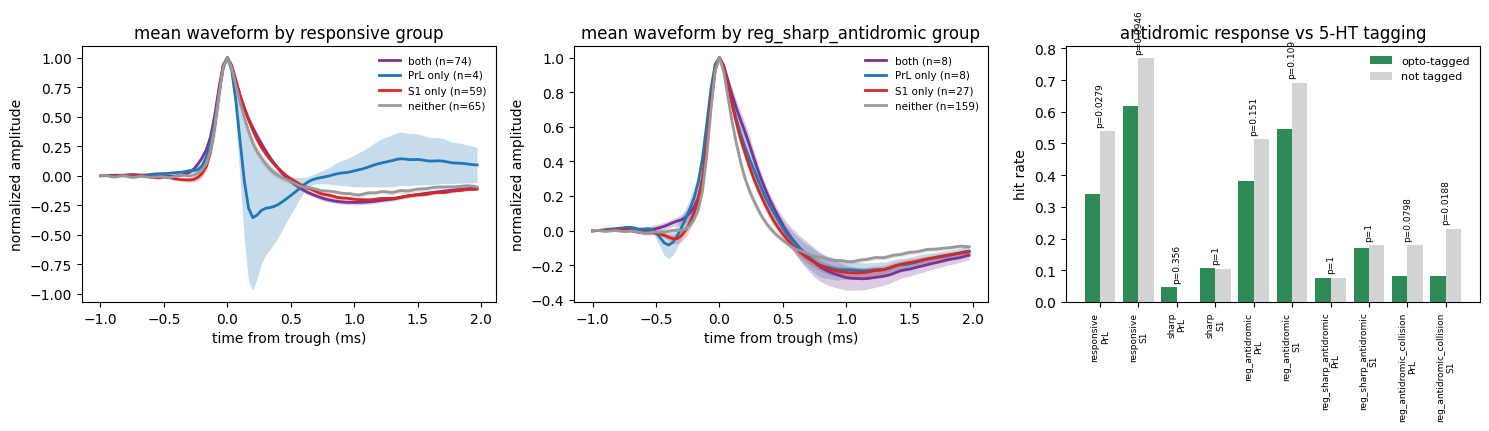

,criterion,focus,rate_tagged,n_tagged,rate_untagged,n_untagged,odds_ratio,p_fisher,p_fdr
0,responsive,PrL,0.3412,170,0.5385,39,0.4439,0.0279,0.1395
1,responsive,S1,0.6176,170,0.7692,39,0.4846,0.0946,0.2178
2,sharp,PrL,0.0471,170,0.0000,39,inf,0.3564,0.5092
3,sharp,S1,0.1059,170,0.1026,39,1.0362,1.0000,1.0000
4,reg_antidromic,PrL,0.3824,170,0.5128,39,0.5881,0.1506,0.2511
5,reg_antidromic,S1,0.5471,170,0.6923,39,0.5368,0.1089,0.2178
6,reg_sharp_antidromic,PrL,0.0765,170,0.0769,39,0.9936,1.0000,1.0000
7,reg_sharp_antidromic,S1,0.1706,170,0.1795,39,0.9402,1.0000,1.0000
8,reg_antidromic_collision,PrL,0.0824,170,0.1795,39,0.4103,0.0798,0.2178
9,reg_antidromic_collision,S1,0.0824,170,0.2308,39,0.2991,0.0188,0.1395


In [24]:
fig, axs = plt.subplots(1, 3, figsize=(15, 4.4))
for ax, crit in zip(axs[:2], [GROUP_CRITERION, SECONDARY_CRITERION]):
    groups = paired[f'group_{crit}']
    valid = paired['wf_norm_valid'].fillna(False).to_numpy()
    for g in GROUP_ORDER:
        m = (groups == g).to_numpy() & valid
        if m.sum() < 3:
            continue
        wfs = np.stack(paired.loc[m, 'wf_nl'].to_numpy())
        mu = np.nanmean(wfs, axis=0)
        sem = np.nanstd(wfs, axis=0) / np.sqrt(np.sum(np.isfinite(wfs), axis=0))
        ax.plot(pc_time, mu, color=GROUP_COLORS[g], linewidth=2, label=f'{g} (n={int(m.sum())})')
        ax.fill_between(pc_time, mu-sem, mu+sem, color=GROUP_COLORS[g], alpha=0.25, linewidth=0)
    ax.set_xlabel('time from trough (ms)'); ax.set_ylabel('normalized amplitude')
    ax.set_title(f'mean waveform by {crit} group')
    ax.legend(frameon=False, fontsize=7.5)

ax = axs[2]
rows = []
for crit in CRITERIA:
    for focus in focuses:
        flag = paired[f'{crit}_{focus}'].astype(int).to_numpy()
        tag = paired['opto_tagged'].astype(bool).to_numpy()
        if flag.sum() < 3:
            continue
        res = binary_shift_X_vs_Y(flag[tag], flag[~tag], permutations=N_PERM_SHIFT, seed=SEED)
        rows.append({'criterion': crit, 'focus': focus,
                     'rate_tagged': res['rate_X'], 'n_tagged': res['n_X'],
                     'rate_untagged': res['rate_Y'], 'n_untagged': res['n_Y'],
                     'odds_ratio': res['odds_ratio_fisher'],
                     'p_fisher': res['p_value_fisher']})
tag_stats = pd.DataFrame(rows)
tag_stats['p_fdr'] = multipletests(tag_stats.p_fisher, method='fdr_bh')[1]
x = np.arange(len(tag_stats))
ax.bar(x - 0.2, tag_stats.rate_tagged, 0.4, color='seagreen', label='opto-tagged')
ax.bar(x + 0.2, tag_stats.rate_untagged, 0.4, color='lightgray', label='not tagged')
for i, r in tag_stats.iterrows():
    ax.text(i, max(r.rate_tagged, r.rate_untagged) + 0.02, fmt_p(r.p_fisher),
            ha='center', fontsize=6.5, rotation=90)
ax.set_xticks(x)
ax.set_xticklabels([f'{r.criterion}\n{r.focus}' for r in tag_stats.itertuples()],
                   rotation=90, fontsize=6.5)
ax.set_ylabel('hit rate'); ax.set_title('antidromic response vs 5-HT tagging')
ax.legend(frameon=False, fontsize=8)
plt.tight_layout()
savefig(fig, 'waveforms_and_tagging')
plt.show()
tag_stats.round(4)

In [25]:
feature_cols = wf_feature_cols + [c for c in ['amp', 'peak', 'snr', 'fr', 'isi_violations',
                                               'y_loc', 'presence_ratio'] if c in paired.columns]
wf_rows = []
for crit in [GROUP_CRITERION, SECONDARY_CRITERION]:
    for focus in focuses:
        flag = paired[f'{crit}_{focus}'].astype(bool).to_numpy()
        for feat in feature_cols:
            v = pd.to_numeric(paired[feat], errors='coerce').to_numpy(float)
            a, b = v[flag], v[~flag]
            a, b = a[np.isfinite(a)], b[np.isfinite(b)]
            if len(a) < 3 or len(b) < 3:
                continue
            res = welch_shift_X_vs_Y(a, b, permutations=2000, seed=SEED, n_boot=1000)
            mw = stats.mannwhitneyu(a, b, alternative='two-sided')
            wf_rows.append({'criterion': crit, 'focus': focus, 'feature': feat,
                            'n_pass': len(a), 'n_fail': len(b),
                            'mean_pass': res['mean_X'], 'mean_fail': res['mean_Y'],
                            'cohens_d': res['cohens_d'],
                            'p_perm': res['p_value_permutation'],
                            'p_mannwhitney': float(mw.pvalue)})
wf_stats = pd.DataFrame(wf_rows)
wf_stats['p_fdr'] = np.nan
for (crit, focus), idx in wf_stats.groupby(['criterion', 'focus']).groups.items():
    wf_stats.loc[idx, 'p_fdr'] = multipletests(wf_stats.loc[idx, 'p_perm'], method='fdr_bh')[1]
wf_stats.sort_values('p_perm').round(4).head(20)

,criterion,focus,feature,n_pass,n_fail,mean_pass,mean_fail,cohens_d,p_perm,p_mannwhitney,p_fdr
11,responsive,PrL,isi_violations,79,130,0.0949,0.1469,-0.4495,0.0020,0.0014,0.0260
14,responsive,S1,trough_post_ratio_1D,70,30,-0.2865,-0.1984,-0.6051,0.0025,0.0036,0.0227
18,responsive,S1,symmetry_trough_dis,70,30,16.8143,7.6667,0.6430,0.0035,0.0058,0.0227
9,responsive,PrL,snr,79,130,4.5406,5.4412,-0.3375,0.0155,0.0082,0.1007
17,responsive,S1,symmetry_slope_div_log,70,30,0.6360,0.2531,0.4833,0.0155,0.0349,0.0671
0,responsive,PrL,post_w,46,54,35.8696,31.2037,0.4455,0.0330,0.1441,0.1429
50,reg_sharp_antidromic,S1,isi_violations,36,173,0.0952,0.1339,-0.3292,0.0380,0.1086,0.4938
13,responsive,S1,post_w,70,30,34.7571,30.0667,0.4462,0.0455,0.1580,0.1478
8,responsive,PrL,peak,79,130,-48.7612,-61.4623,0.2909,0.0470,0.0115,0.1527
5,responsive,PrL,symmetry_trough_dis,46,54,16.9565,11.6111,0.3662,0.0765,0.0954,0.1988


saved /root/capsule/scratch/results/manuscript/figures/F_antidromic_DRN/waveform_feature_effects


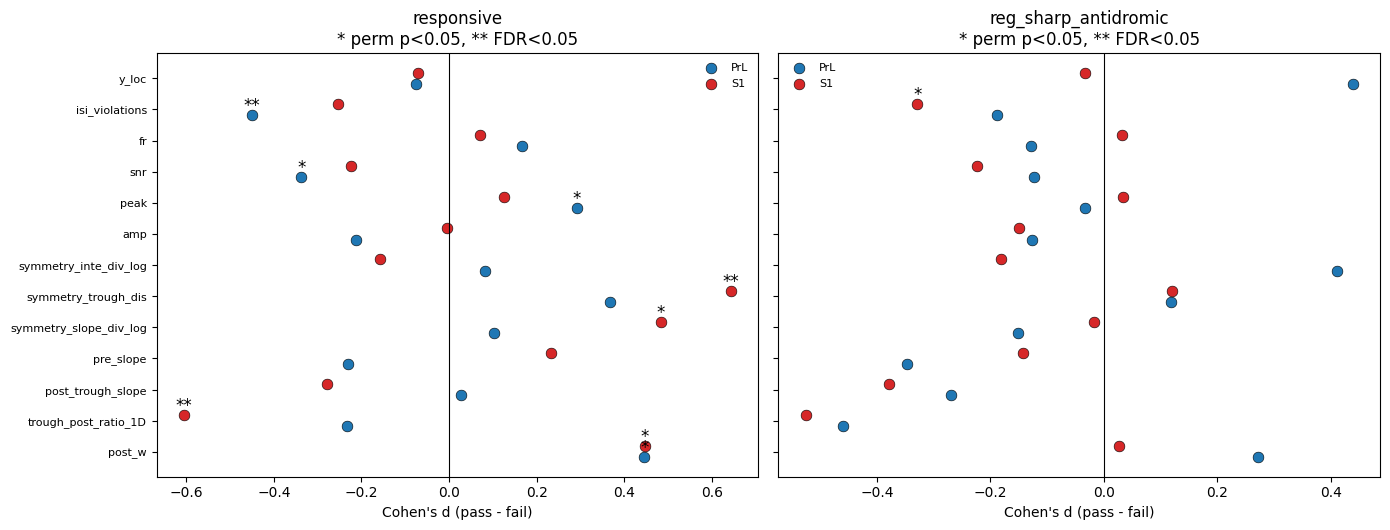

In [26]:
fig, axs = plt.subplots(1, 2, figsize=(14, 5.4), sharey=True)
for ax, crit in zip(axs, [GROUP_CRITERION, SECONDARY_CRITERION]):
    sub = wf_stats.query('criterion == @crit')
    feats = [f for f in feature_cols if f in set(sub.feature)]
    y = np.arange(len(feats))
    for focus, off in zip(focuses, [-0.18, 0.18]):
        s = sub.query('focus == @focus').set_index('feature').reindex(feats)
        ax.scatter(s.cohens_d, y + off, s=60, color=FOCUS_COLORS[focus], label=focus,
                   edgecolor='k', linewidth=0.4)
        for i, (d_, p_, pf) in enumerate(zip(s.cohens_d, s.p_perm, s.p_fdr)):
            if np.isfinite(p_) and p_ < 0.05:
                ax.text(d_, y[i] + off, '*' if pf >= 0.05 else '**', fontsize=12,
                        ha='center', va='bottom')
    ax.axvline(0, color='k', linewidth=0.8)
    ax.set_yticks(y); ax.set_yticklabels(feats, fontsize=8)
    ax.set_xlabel("Cohen's d (pass - fail)")
    ax.set_title(f'{crit}\n* perm p<0.05, ** FDR<0.05')
    ax.legend(frameon=False, fontsize=8)
plt.tight_layout()
savefig(fig, 'waveform_feature_effects')
plt.show()

## 10. Agreement between the two tier schemes

The nested per-session tiers and the regression flags use different statistics, alphas and
jitter gates. Any statement about "antidromic units" therefore has to name its scheme.

In [27]:
agree_rows = []
for focus in focuses:
    sub = long[long.focus == focus]
    for a, b in [('responsive', 'reg_antidromic'), ('sharp', 'reg_sharp_antidromic'),
                 ('collision_confirmed', 'reg_antidromic_collision')]:
        x, y = sub[a].astype(bool), sub[b].astype(bool)
        agree_rows.append({'focus': focus, 'tier_scheme': a, 'regression_scheme': b,
                           'n': len(sub), 'both': int((x & y).sum()),
                           'tier_only': int((x & ~y).sum()), 'reg_only': int((~x & y).sum()),
                           'neither': int((~x & ~y).sum()),
                           'kappa': cohen_kappa_score(x, y),
                           'p_mcnemar': float(mcnemar(np.array([[int((x & y).sum()), int((x & ~y).sum())],
                                                                [int((~x & y).sum()), int((~x & ~y).sum())]]),
                                                      exact=True).pvalue)})
agreement = pd.DataFrame(agree_rows)
print(agreement.round(4).to_string(index=False))
print()
print('tier label x regression sharp_antidromic, per site:')
for focus in focuses:
    sub = long[long.focus == focus]
    print(f'--- {focus}')
    print(pd.crosstab(sub.antidromic_tier_label, sub.reg_sharp_antidromic, dropna=False))

focus         tier_scheme        regression_scheme   n  both  tier_only  reg_only  neither  kappa  p_mcnemar
  PrL          responsive           reg_antidromic 209    60         19        25      105 0.5589     0.4514
  PrL               sharp     reg_sharp_antidromic 209     6          2        10      191 0.4731     0.0386
  PrL collision_confirmed reg_antidromic_collision 209     0          0        21      188 0.0000     0.0000
   S1          responsive           reg_antidromic 209   115         20         5       69 0.7499     0.0041
   S1               sharp     reg_sharp_antidromic 209    18          4        18      169 0.5637     0.0043
   S1 collision_confirmed reg_antidromic_collision 209     0          0        23      186 0.0000     0.0000

tier label x regression sharp_antidromic, per site:
--- PrL
reg_sharp_antidromic   False  True 
antidromic_tier_label              
jitter                     2      6
none                     127      3
responsive                64    

## 11. Save tidy tables

In [28]:
out_dir = os.path.join(target_folder, 'tables')
os.makedirs(out_dir, exist_ok=True)

drop_obj = ['wf_nl']
long_out = long.drop(columns=[c for c in drop_obj if c in long.columns])
paired_out = paired.drop(columns=[c for c in drop_obj if c in paired.columns])

saved = {}
for name, df in [('per_unit_site', long_out), ('per_unit_paired', paired_out),
                 ('hit_rates', hit_rates), ('cluster_level_stats', cluster_stats),
                 ('timing_stats', timing_stats), ('axis_stats', axis_stats),
                 ('spatial_stats', spatial_stats), ('waveform_stats', wf_stats),
                 ('tagging_stats', tag_stats), ('tier_scheme_agreement', agreement),
                 ('stim_parameters', stim)]:
    path = os.path.join(out_dir, f'{name}.csv')
    df.to_csv(path, index=False)
    saved[name] = (len(df), path)
    print(f'{name:24s} {len(df):5d} rows -> {path}')

summary = {
    'criteria_name': criteria_name,
    'data_type': data_type,
    'n_units': int(len(paired)),
    'n_sessions': int(long.session.nunique()),
    'n_animals': int(long.subject.nunique()),
    'n_opto_tagged': int(paired.opto_tagged.astype(bool).sum()),
    'group_criterion': GROUP_CRITERION,
    'secondary_criterion': SECONDARY_CRITERION,
    'hit_rates': hit_rates.to_dict(orient='records'),
    'session_level': cluster_stats.to_dict(orient='records'),
}
with open(os.path.join(out_dir, 'summary.json'), 'w') as f:
    json.dump(summary, f, indent=2, default=float)
print('\nsummary.json written')

per_unit_site              418 rows -> /root/capsule/scratch/results/manuscript/figures/F_antidromic_DRN/tables/per_unit_site.csv
per_unit_paired            209 rows -> /root/capsule/scratch/results/manuscript/figures/F_antidromic_DRN/tables/per_unit_paired.csv
hit_rates                    6 rows -> /root/capsule/scratch/results/manuscript/figures/F_antidromic_DRN/tables/hit_rates.csv
cluster_level_stats         12 rows -> /root/capsule/scratch/results/manuscript/figures/F_antidromic_DRN/tables/cluster_level_stats.csv
timing_stats                 5 rows -> /root/capsule/scratch/results/manuscript/figures/F_antidromic_DRN/tables/timing_stats.csv
axis_stats                  30 rows -> /root/capsule/scratch/results/manuscript/figures/F_antidromic_DRN/tables/axis_stats.csv
spatial_stats                4 rows -> /root/capsule/scratch/results/manuscript/figures/F_antidromic_DRN/tables/spatial_stats.csv
waveform_stats              52 rows -> /root/capsule/scratch/results/manuscript/figures/F_

## 12. Notes for interpretation

- **Site is perfectly confounded with block order.** Every session ran
  DRN -> PrL -> S1 (-> BLA), blocked, with no time overlap between the PrL and S1 trials and
  no session in the reverse order. Spontaneous (pre-pulse) spike probability already differs
  between the two blocks, so "S1 > PrL" is equally consistent with "block 3 > block 2"
  (drift, state, light-induced heating/adaptation from the earlier blocks). Section 4b bounds
  how much of the effect scales with the block-to-block state change, but nothing in this
  dataset can separate the two: that needs order-counterbalanced sessions, or interleaved
  site delivery.
- **S1 out-hits PrL.** Beyond block order, the methodological explanations to rule out are
  fiber placement / light spread at the S1 window and conduction distance. The
  stimulation-parameter check only rules out power, pulse-count and trial-count differences;
  it says nothing about placement.
- **Collision is the only specific test**, and nothing passes it in this set. At the
  population level the direction is right -- P(antidromic spike) is lower when the last
  orthodromic spike fell inside the collision window than outside it, at both sites -- but no
  individual unit clears the per-unit Fisher test, and `collision_pbinom > 0.05` demands
  literally zero spikes in the window (the binomial null is p=0). Sharp short-latency
  responses without a collision block are equally consistent with synaptically driven
  cortical input reaching DR.
- **Pseudoreplication.** Unit-level n is inflated: units come from many fewer sessions and
  animals. Trust the session/animal-level rows in `cluster_level_stats`, not the unit-level
  p-values, for any population claim.
- **|ML| is mirrored**, so ML effects are medial <-> lateral, not left <-> right. The DR
  mesh is an overlay only; no anatomical inclusion criterion is applied.
- **Two tier schemes**, as tabulated in section 10. Never aggregate the numeric
  `antidromic_tier` code with `max()`/`>=`: 0 means "no evidence" but sorts below 1, the
  strongest tier. Use the label or the boolean flags.